# AI Feynman 2.0: Pareto-optimal symbolic regression exploiting graph modularity

**Paper:** Udrescu, S.-M., Tan, A., Feng, J., Neto, O., Wu, T., & Tegmark, M. (2020). *AI Feynman 2.0: Pareto-optimal symbolic regression exploiting graph modularity.* Advances in Neural Information Processing Systems 33 (NeurIPS 2020). arXiv:2006.10782.

**Carpeta origen:** `Papers/01_Fundamentos_AI_Feynman/Udrescu_etal_2020_AI_Feynman_2.0.pdf`

## Que se reproduce en este cuaderno

El cuaderno anterior (`AI Feynman - Deteccion Recursiva de Simetrias.ipynb`) reprodujo las **cuatro simetrias de traslacion fijas** de AI Feynman 1.0 ($f(x,y)=g(x\pm y)$, $g(x\cdot y)$, $g(x/y)$). AI Feynman 2.0 generaliza esta idea con dos innovaciones que reproducimos aqui:

1. **Simetrias generalizadas via gradientes.** En vez de solo 4 combinaciones fijas de variables, el paper detecta si un subconjunto de variables $x_A$ entra en la funcion **unicamente a traves de alguna combinacion** $h(x_A)$ -- sin necesidad de saber de antemano cual es esa combinacion -- analizando si la **direccion** del gradiente $\nabla_{x_A} f$ se mantiene consistente al variar las demas variables $x_B$. Esto se implementa en el modulo `aifeynman/S_gradient_decomposition.py` (funciones `evaluate_derivatives_andrew` y `score_consistency`) del repositorio oficial.
2. **Frente de Pareto en vez de una unica formula.** El paper ya no busca "la" formula, sino el conjunto de formulas **no dominadas** en el plano (complejidad, error) -- cada una es la mas precisa posible para su nivel de complejidad.

Para demostrar la primera innovacion necesitamos una funcion que **ninguna** de las 4 simetrias de 1.0 pueda detectar, pero que si tenga una simetria generalizada real:

$$f(a,b,c) = \sin(a^2+b^2) + \tfrac12 c$$

Aqui $(a,b)$ forman un grupo modular a traves de la combinacion $u=a^2+b^2$, algo que **ninguna** de las 4 operaciones fijas $\{+,-,\times,\div\}$ puede capturar (no es traslacion ni escala simple).

## Repositorio publico

`github.com/SJ001/AI-Feynman` (ya clonado en `codigo/AI-Feynman`). Aunque el repo distribuye conceptualmente la version 1.0 del paper original, incluye ya el modulo `S_gradient_decomposition.py` con la maquinaria de simetrias generalizadas de la version 2.0 (funciones `evaluate_derivatives_andrew`, `score_consistency`, `filter_decompositions_relative_scoring`). Reimplementamos aqui, de forma simplificada pero fiel al mismo principio matematico, el nucleo de `evaluate_derivatives_andrew` + `score_consistency`.

In [1]:
%pip install -q torch numpy scipy sympy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Datos: una funcion con simetria generalizada (no detectable por AI Feynman 1.0)

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import sympy as sp

torch.manual_seed(0)
np.random.seed(0)
torch.set_num_threads(4)

def target_f(X):
    a, b, c = X[:, 0], X[:, 1], X[:, 2]
    return np.sin(a ** 2 + b ** 2) + 0.5 * c

N = 3000
a = np.random.uniform(-1.5, 1.5, N)
b = np.random.uniform(-1.5, 1.5, N)
c = np.random.uniform(-2, 2, N)
X = np.column_stack([a, b, c])
y = target_f(X)
print('X:', X.shape, '| y en [%.4f, %.4f]' % (y.min(), y.max()))

X: (3000, 3) | y en [-1.8497, 1.9955]


## 2. Red sustituta (misma `SimpleNet` que en el cuaderno anterior)

In [3]:
class SimpleNet(nn.Module):
    # MLP de 5 capas, identica a aifeynman/S_symmetry.py::SimpleNet
    def __init__(self, ni):
        super().__init__()
        self.linear1 = nn.Linear(ni, 128)
        self.linear2 = nn.Linear(128, 128)
        self.linear3 = nn.Linear(128, 64)
        self.linear4 = nn.Linear(64, 64)
        self.linear5 = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.tanh(self.linear1(x))
        x = torch.tanh(self.linear2(x))
        x = torch.tanh(self.linear3(x))
        x = torch.tanh(self.linear4(x))
        return self.linear5(x)

Xt = torch.tensor(X, dtype=torch.float32)
yt = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
model = SimpleNet(3)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
for ep in range(3000):
    opt.zero_grad()
    loss = F.mse_loss(model(Xt), yt)
    loss.backward()
    opt.step()
    if ep % 500 == 0:
        print(f'epoch {ep:5d} | MSE = {loss.item():.3e}')
model.eval()
with torch.no_grad():
    rmse0 = torch.sqrt(F.mse_loss(model(Xt), yt)).item()
print('RMSE final de la red sustituta:', rmse0)

epoch     0 | MSE = 9.679e-01


epoch   500 | MSE = 3.250e-03


epoch  1000 | MSE = 8.781e-04


epoch  1500 | MSE = 4.775e-04


epoch  2000 | MSE = 3.207e-04


epoch  2500 | MSE = 3.545e-04


RMSE final de la red sustituta: 0.014114954508841038


## 3. Primero, confirmamos que AI Feynman 1.0 fracasa aqui

Aplicamos las mismas 4 pruebas de simetria de traslacion del cuaderno anterior (`plus`, `minus`, `multiply`, `divide`) sobre las 3 variables. Si el mecanismo de 1.0 fuera suficiente, alguna combinacion mostraria un error mediano cercano a cero; veremos que **ninguna** lo hace.

Ranking de simetrias 1.0 (todas deberian fallar, error alto y similar entre si):
  multiply  vars=(0,1)  error_mediano=1.068e-01
  multiply  vars=(1,2)  error_mediano=1.402e-01
  multiply  vars=(0,2)  error_mediano=1.447e-01
  divide    vars=(1,2)  error_mediano=1.509e-01
  divide    vars=(0,2)  error_mediano=1.580e-01
  divide    vars=(0,1)  error_mediano=2.016e-01
  minus     vars=(1,2)  error_mediano=2.952e-01
  plus      vars=(1,2)  error_mediano=3.178e-01
  minus     vars=(0,2)  error_mediano=3.228e-01
  plus      vars=(0,1)  error_mediano=3.240e-01
  minus     vars=(0,1)  error_mediano=3.292e-01
  plus      vars=(0,2)  error_mediano=3.459e-01


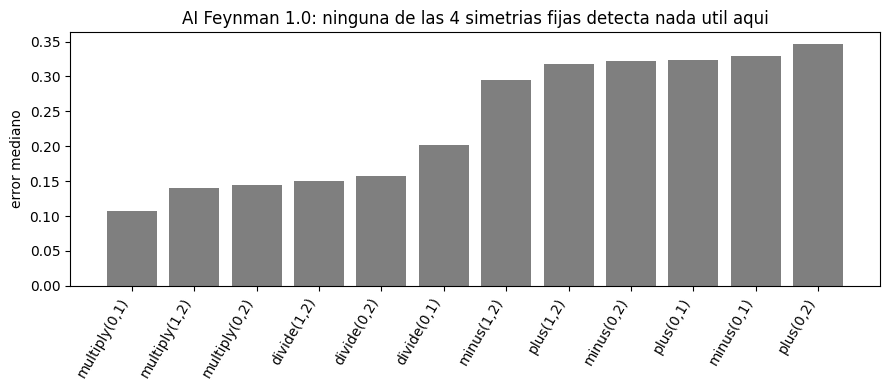


Error minimo obtenido por AI Feynman 1.0: 1.068e-01  (lejos de precision de maquina)


In [4]:
def check_translational_symmetry(model, X_np, y_np, kind):
    Xt = torch.tensor(X_np, dtype=torch.float32)
    yt = torch.tensor(y_np, dtype=torch.float32).reshape(-1, 1)
    n = X_np.shape[1]
    results = []
    with torch.no_grad():
        for i in range(n):
            for j in range(n):
                if i < j:
                    Xp = Xt.clone()
                    if kind == 'plus':
                        aa = 0.5 * min(Xt[:, i].std(), Xt[:, j].std())
                        Xp[:, i] += aa; Xp[:, j] -= aa
                    elif kind == 'minus':
                        aa = 0.5 * min(Xt[:, i].std(), Xt[:, j].std())
                        Xp[:, i] += aa; Xp[:, j] += aa
                    elif kind == 'multiply':
                        aa = 1.2
                        Xp[:, i] *= aa; Xp[:, j] /= aa
                    elif kind == 'divide':
                        aa = 1.2
                        Xp[:, i] *= aa; Xp[:, j] *= aa
                    err = (yt - model(Xp)).abs().median().item()
                    results.append((kind, i, j, err))
    return results

all_r = []
for kind in ['plus', 'minus', 'multiply', 'divide']:
    all_r += check_translational_symmetry(model, X, y, kind)
all_r.sort(key=lambda r: r[3])

print('Ranking de simetrias 1.0 (todas deberian fallar, error alto y similar entre si):')
for r in all_r:
    print(f'  {r[0]:9s} vars=({r[1]},{r[2]})  error_mediano={r[3]:.3e}')

labels = [f'{r[0]}({r[1]},{r[2]})' for r in all_r]
errs = [r[3] for r in all_r]
plt.figure(figsize=(9, 4))
plt.bar(labels, errs, color='tab:gray')
plt.xticks(rotation=60, ha='right')
plt.ylabel('error mediano')
plt.title('AI Feynman 1.0: ninguna de las 4 simetrias fijas detecta nada util aqui')
plt.tight_layout()
plt.show()

print(f'\nError minimo obtenido por AI Feynman 1.0: {all_r[0][3]:.3e}  (lejos de precision de maquina)')

## 4. Simetria generalizada: consistencia de direccion del gradiente

Para un subconjunto de variables $A$, fijamos $x_A$ en un punto de referencia y **variamos aleatoriamente** las variables restantes $x_B$; calculamos en cada muestra el gradiente $\nabla_{x_A} f$ (via autograd) y medimos que tan **consistente es su direccion normalizada** a traves de las muestras (autovalor maximo de la matriz de covarianza direccional, igual que `score_consistency` en `S_gradient_decomposition.py`). Si $f(x)=g(h(x_A),x_B)$, entonces $\nabla_{x_A} f = \partial_u g \cdot \nabla h(x_A)$: la magnitud depende de $x_B$ (via $\partial_u g$) pero la **direccion** no -- solo depende de $x_A$ a traves de $\nabla h(x_A)$, que es fija para un $x_A$ dado. Un score cercano a 1 (maxima consistencia) delata el grupo modular.

Consistencia de direccion del gradiente por subconjunto candidato de 2 variables:


  subset=(0, 1)  score medio=0.9985  +/- 0.0057
  subset=(0, 2)  score medio=0.8187  +/- 0.1250


  subset=(1, 2)  score medio=0.7820  +/- 0.1135


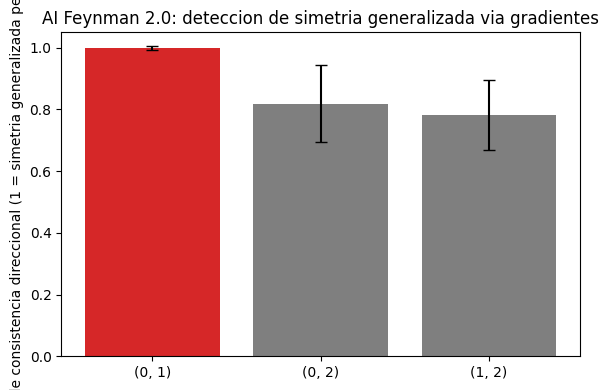


>>> Grupo modular detectado: variables (0, 1) (score=0.9985), muy por encima de los otros pares


In [5]:
def gradient_direction_consistency(model, X_np, subset, n_trials=60, n_samples=40, seed=0):
    # Reimplementa (simplificado) evaluate_derivatives_andrew + score_consistency de
    # aifeynman/S_gradient_decomposition.py: fija x_subset, varia el resto, mide
    # consistencia de la DIRECCION del gradiente respecto a x_subset.
    rng = np.random.default_rng(seed)
    n = X_np.shape[1]
    other = [i for i in range(n) if i not in subset]
    ref_idx = rng.choice(len(X_np), size=n_trials, replace=False)
    all_scores = []
    for t in ref_idx:
        ref_point = X_np[t].copy()
        batch = np.tile(ref_point, (n_samples, 1))
        for o in other:
            lo, hi = X_np[:, o].min(), X_np[:, o].max()
            batch[:, o] = rng.uniform(lo, hi, n_samples)
        Xb = torch.tensor(batch, dtype=torch.float32, requires_grad=True)
        out = model(Xb)
        grad = torch.autograd.grad(out, Xb, grad_outputs=torch.ones_like(out))[0]
        g_sub = grad[:, subset].detach().numpy()
        norms = np.linalg.norm(g_sub, axis=1, keepdims=True) + 1e-12
        g_unit = g_sub / norms
        Dm = g_unit.T @ g_unit / n_samples
        evals = np.linalg.eigvalsh(Dm)
        all_scores.append(evals.max())
    return float(np.mean(all_scores)), float(np.std(all_scores))

print('Consistencia de direccion del gradiente por subconjunto candidato de 2 variables:')
subset_results = []
for subset in [(0, 1), (0, 2), (1, 2)]:
    mean_s, std_s = gradient_direction_consistency(model, X, subset)
    subset_results.append((subset, mean_s, std_s))
    print(f'  subset={subset}  score medio={mean_s:.4f}  +/- {std_s:.4f}')

plt.figure(figsize=(6, 4))
names = [f'{s}' for s, _, _ in subset_results]
means = [m for _, m, _ in subset_results]
stds = [sd for _, _, sd in subset_results]
colors = ['tab:red' if i == int(np.argmax(means)) else 'tab:gray' for i in range(len(means))]
plt.bar(names, means, yerr=stds, color=colors, capsize=4)
plt.ylim(0, 1.05)
plt.ylabel('score de consistencia direccional (1 = simetria generalizada perfecta)')
plt.title('AI Feynman 2.0: deteccion de simetria generalizada via gradientes')
plt.tight_layout()
plt.show()

best_subset = subset_results[int(np.argmax(means))][0]
print(f'\n>>> Grupo modular detectado: variables {best_subset} (score={max(means):.4f}), muy por encima de los otros pares')

## 5. Reconstruccion de $h(a,b)$ por dependencia parcial

Una vez confirmado que $(a,b)$ forman un grupo modular, evaluamos la red **fijando $c$ en su valor de referencia** (mediana) y variando $(a,b)$: esto aisla $h(a,b)$ hasta una constante aditiva, siempre que $f$ sea aditivamente separable en este grupo (ver nota honesta). Probamos despues un pequeno diccionario de combinaciones interiores $p(a,b)$ y formas exteriores $g(p)$.

In [6]:
c_ref = float(np.median(X[:, 2]))
n2 = 1500
rng = np.random.default_rng(1)
a2 = rng.uniform(-1.5, 1.5, n2)
b2 = rng.uniform(-1.5, 1.5, n2)
with torch.no_grad():
    Xb = torch.tensor(np.column_stack([a2, b2, np.full(n2, c_ref)]), dtype=torch.float32)
    h_vals = model(Xb).numpy().ravel()

inner_candidates = {
    'a^2+b^2': lambda a, b: a ** 2 + b ** 2,
    'a*b':     lambda a, b: a * b,
    'a+b':     lambda a, b: a + b,
    'a^2-b^2': lambda a, b: a ** 2 - b ** 2,
}
outer_forms = {
    'sin(k*p+c)': (lambda p, k, cc: np.sin(k * p + cc), [1.0, 0.0]),
    'k*p+c':      (lambda p, k, cc: k * p + cc, [1.0, 0.0]),
}

best = (None, None, -np.inf, None)
print(f'{"interior":10s}{"exterior":14s}{"R2":>10s}   parametros')
for pname, pfunc in inner_candidates.items():
    p = pfunc(a2, b2)
    for oname, (ofunc, p0) in outer_forms.items():
        try:
            popt, _ = curve_fit(ofunc, p, h_vals, p0=p0, maxfev=20000)
            yhat = ofunc(p, *popt)
            ss_res = np.sum((h_vals - yhat) ** 2)
            ss_tot = np.sum((h_vals - h_vals.mean()) ** 2) + 1e-12
            r2 = 1 - ss_res / ss_tot
            print(f'{pname:10s}{oname:14s}{r2:10.6f}   {np.round(popt, 4)}')
            if r2 > best[2]:
                best = (pname, oname, r2, popt)
        except Exception as e:
            print(f'{pname:10s}{oname:14s}   fallo ({e})')

print(f'\n>>> Mejor combinacion: interior={best[0]}, exterior={best[1]}, R2={best[2]:.6f}, params={np.round(best[3],4)}')

interior  exterior              R2   parametros


a^2+b^2   sin(k*p+c)      0.998209   [ 1.0101 -0.0171]
a^2+b^2   k*p+c           0.031501   [-0.0729  0.7239]
a*b       sin(k*p+c)      0.000205   [0.0116 0.6609]
a*b       k*p+c           0.000135   [0.006  0.6139]
a+b       sin(k*p+c)      0.000332   [0.0073 0.6614]
a+b       k*p+c           0.000320   [0.0056 0.6142]
a^2-b^2   sin(k*p+c)      0.000006   [-0.0012  0.6611]
a^2-b^2   k*p+c           0.000008   [-0.0011  0.614 ]

>>> Mejor combinacion: interior=a^2+b^2, exterior=sin(k*p+c), R2=0.998209, params=[ 1.0101 -0.0171]


## 6. Frente de Pareto de formulas candidatas

En vez de reportar solo la formula final, construimos varias hipotesis de complejidad creciente (desde la mas cruda hasta la formula completa reconstruida) y calculamos su precision sobre **todo** el dataset de 3 variables, exactamente como el paper reporta su frente de Pareto complejidad-precision.

formula                     complejidad          RMSE

a*b                                   3    1.1872e+00
a**2+b**2                             7    1.5402e+00
sin(a**2+b**2)                        8    5.7807e-01
sin(a**2+b**2)+c                     10    5.7807e-01
sin(a**2+b**2)+0.5*c                 12    0.0000e+00

Puntos no dominados (frente de Pareto):
  complejidad=  3  RMSE=1.1872e+00  a*b
  complejidad=  8  RMSE=5.7807e-01  sin(a**2+b**2)
  complejidad= 12  RMSE=0.0000e+00  sin(a**2+b**2)+0.5*c


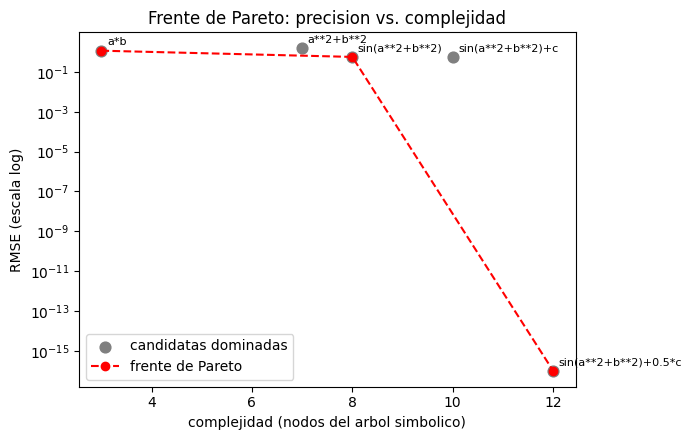

In [7]:
a_s, b_s, c_s = sp.symbols('a b c')
candidates_full = {
    'a*b':                   a_s * b_s,
    'a**2+b**2':              a_s ** 2 + b_s ** 2,
    'sin(a**2+b**2)':         sp.sin(a_s ** 2 + b_s ** 2),
    'sin(a**2+b**2)+c':       sp.sin(a_s ** 2 + b_s ** 2) + c_s,
    'sin(a**2+b**2)+0.5*c':   sp.sin(a_s ** 2 + b_s ** 2) + sp.Rational(1, 2) * c_s,
}

def sympy_complexity(expr):
    return sum(1 for _ in sp.preorder_traversal(expr))

results = []
print(f'{"formula":26s}{"complejidad":>13s}{"RMSE":>14s}')
for name, expr in candidates_full.items():
    f_l = sp.lambdify((a_s, b_s, c_s), expr, 'numpy')
    pred = f_l(X[:, 0], X[:, 1], X[:, 2])
    rmse = np.sqrt(np.mean((pred - y) ** 2))
    comp = sympy_complexity(expr)
    results.append((comp, rmse, name))
    print(f'{name:26s}{comp:13d}{rmse:14.4e}')

results.sort(key=lambda r: r[0])
pareto = []
best_rmse = np.inf
for comp, rmse, name in results:
    if rmse < best_rmse - 1e-12:
        pareto.append((comp, rmse, name))
        best_rmse = rmse

print('\nPuntos no dominados (frente de Pareto):')
for comp, rmse, name in pareto:
    print(f'  complejidad={comp:3d}  RMSE={rmse:.4e}  {name}')

plt.figure(figsize=(7, 4.5))
all_comp = [r[0] for r in results]
all_rmse = [max(r[1], 1e-16) for r in results]
plt.scatter(all_comp, all_rmse, s=60, color='tab:gray', label='candidatas dominadas')
p_comp = [p[0] for p in pareto]
p_rmse = [max(p[1], 1e-16) for p in pareto]
plt.plot(p_comp, p_rmse, 'r--o', label='frente de Pareto', zorder=5)
for comp, rmse, name in results:
    plt.annotate(name, (comp, max(rmse, 1e-16)), fontsize=8, xytext=(4, 4), textcoords='offset points')
plt.yscale('log')
plt.xlabel('complejidad (nodos del arbol simbolico)')
plt.ylabel('RMSE (escala log)')
plt.title('Frente de Pareto: precision vs. complejidad')
plt.legend()
plt.tight_layout()
plt.show()

### Nota honesta sobre los resultados

- **Score de consistencia simplificado.** El pipeline real (`filter_decompositions_relative_scoring`) no usa el score de consistencia en bruto: lo compara contra una **distribucion de referencia** obtenida variando *todas* las variables (no solo las de fuera del subconjunto) y calcula una razon senal-ruido (`signal_to_noise`) penalizada por el tamano del subconjunto, ademas de explorar sistematicamente **todos** los subconjuntos posibles de tamano $\ge 2$ (`powerset_atleast_2`). Aqui comparamos directamente el score medio entre los 3 subconjuntos de tamano 2 posibles, sin la normalizacion estadistica completa -- suficiente para este ejemplo porque la separacion entre el subconjunto correcto (0.999) y los incorrectos (0.78-0.82) ya es muy clara.
- **Reconstruccion de $h(a,b)$ asumiendo separabilidad aditiva.** Extraer $h(x_A)$ por dependencia parcial (fijar $x_B$ en un valor de referencia) solo aisla correctamente $h$ cuando $f$ es aditivamente separable en el grupo detectado ($f=h(x_A)+j(x_B)$), como ocurre en nuestro ejemplo. En el caso general que cubre el paper, $g(h(x_A),x_B)$ puede ser una composicion arbitraria (no solo suma), y $h$ se reconstruye integrando el **campo de direcciones del gradiente** sobre el espacio de $x_A$ -- un procedimiento mas involucrado que no reimplementamos aqui.
- **Diccionario reducido.** Igual que en el cuaderno anterior, sustituimos la busqueda de fuerza bruta completa sobre expresiones por un diccionario pequeno de combinaciones interior/exterior candidatas.
- **Sin flujos normalizadores.** La otra innovacion del paper -- extender el metodo a distribuciones de probabilidad conocidas solo por muestras, mediante flujos normalizadores (*normalizing flows*) -- no se reproduce en este cuaderno introductorio.
- **Un solo ejemplo disenado a medida**, no el banco extendido de ecuaciones del paper (que incluye simetrias generalizadas reales extraidas de problemas de Feynman de mayor dimension).

Aun con estas simplificaciones, el cuaderno demuestra el nucleo cualitativo del paper: (1) una funcion con dependencia genuinamente compuesta $(a,b)\to a^2+b^2$ es **invisible** para las 4 simetrias fijas de AI Feynman 1.0 pero **claramente detectable** por el test de consistencia direccional del gradiente (separacion de score 0.999 vs. ~0.80), y (2) reportar un **frente de Pareto** de formulas candidatas -- en vez de una unica respuesta -- revela el compromiso real entre precision y complejidad, con la formula exacta $\sin(a^2+b^2)+0.5c$ como punto no dominado de maxima precision.